In [ ]:
# Demo: NER + Image Classification Pipeline

In [5]:
import json
from pathlib import Path

import torch
import torch.nn as nn
from PIL import Image

import matplotlib.pyplot as plt
import torchvision.transforms as T
from torchvision.models import efficientnet_b4

from transformers import AutoTokenizer, AutoConfig, AutoModelForTokenClassification

from notebooks.pipeline import load_cv_model, load_ner_model, predict_image_animal, predict_text_animal, run_pipeline

In [6]:
PROJECT_ROOT = Path.cwd()

comp_path = PROJECT_ROOT / "models"
data_path = PROJECT_ROOT / "data" / "animal_test"

model_cv_path = comp_path / "animals_efficientNetB4" / "best_model.pth"
model_ner_path = comp_path / "ner_bert" / "best_ner_model.pth"
tokenizer_path = comp_path / "ner_bert" / "tokenizer"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained(str(tokenizer_path))

with open(comp_path / "animals_efficientNetB4" / "idx_to_class.json", "r") as f:
    idx_to_class = {int(k): v for k, v in json.load(f).items()}

with open(comp_path / "ner_bert" / "id_to_label.json", "r") as f:
    id_to_label = {int(k): v for k, v in json.load(f).items()}

In [7]:
cv_model = load_cv_model(
    model_path=model_cv_path,
    num_classes=len(idx_to_class),
    device=device
)

ner_model = load_ner_model(
    model_path=model_ner_path,
    num_labels=len(id_to_label),
    device=device
)

print("Models loaded successfully.")
print(f"Device: {device}")

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 7136.37it/s]
BertForTokenClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expec

Models loaded successfully.
Device: cpu


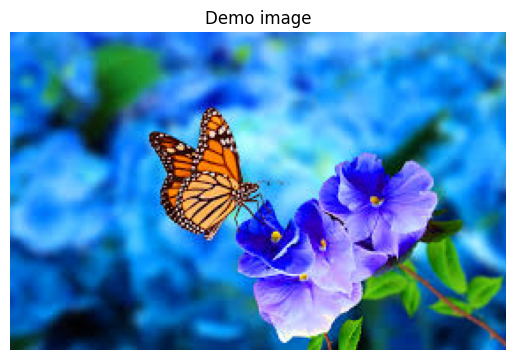

Input text: There is a cow in the picture.
Text animal: cow
Image animal: butterfly
Match: False


In [8]:
text = "There is a cow in the picture."
image_path = data_path / "butterfly2.jpeg" 

image = Image.open(image_path).convert("RGB")
plt.imshow(image)
plt.title("Demo image")
plt.axis("off")
plt.show()

result = run_pipeline(
    text=text,
    image_path=image_path,
    cv_model=cv_model,
    ner_model=ner_model,
    tokenizer=tokenizer,
    idx_to_class=idx_to_class,
    id_to_label=id_to_label,
    device=device
)

print("Input text:", text)
print("Text animal:", result["text_animal"])
print("Image animal:", result["image_animal"])
print("Match:", result["match"])